# LOGISTIC REGRESSION CLASSIFIER

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

print("Logistic Regression notebook setup completed.")

Logistic Regression notebook setup completed.


In [2]:
from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/ML Assignment"
FINAL_MODEL_DIR = os.path.join(BASE_DIR, "final_dataset")

LR_DIR = os.path.join(BASE_DIR, "logistic_regression")
os.makedirs(LR_DIR, exist_ok=True)

print("Final Model Directory :", FINAL_MODEL_DIR)
print("Logistic Regression directory:", LR_DIR)

Mounted at /content/drive
Final Model Directory : /content/drive/MyDrive/ML Assignment/final_dataset
Logistic Regression directory: /content/drive/MyDrive/ML Assignment/logistic_regression


Load final model-ready dataset

In [3]:
X_train_final = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "X_train_logistic.csv")
)

X_val_final = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "X_validation_logistic.csv")
)

X_test_final = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "X_test_logistic.csv")
)

# MODEL A: remove all market features (including market_missing)
MARKET_COLS = [c for c in X_train_final.columns if c.startswith("market_")]
X_train_final = X_train_final.drop(columns=MARKET_COLS, errors="ignore")
X_val_final   = X_val_final.drop(columns=MARKET_COLS, errors="ignore")
X_test_final  = X_test_final.drop(columns=MARKET_COLS, errors="ignore")

assert not any(c.startswith("market_") for c in X_train_final.columns)
print("Dropped market columns:", MARKET_COLS)

y_train_encoded = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "y_train.csv")
).squeeze("columns")

y_val_encoded = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "y_validation.csv")
).squeeze("columns")

y_test_encoded = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "y_test.csv")
).squeeze("columns")

target_encoder = joblib.load(os.path.join(FINAL_MODEL_DIR, "target_encoder.joblib"))

print("Matrix Shapes:")
print(f"  Training   : {X_train_final.shape} | Labels: {y_train_encoded.shape}")
print(f"  Validation : {X_val_final.shape}  | Labels: {y_val_encoded.shape}")
print(f"  Test       : {X_test_final.shape}  | Labels: {y_test_encoded.shape}")

print("\nTarget Class Mapping:")
for idx, label in enumerate(target_encoder.classes_):
    print(f"  {idx} -> {label}")

# Verify data alignment
assert list(X_train_final.columns) == list(X_val_final.columns) == list(X_test_final.columns)
assert len(X_train_final) == len(y_train_encoded)
assert len(X_val_final) == len(y_val_encoded)
assert len(X_test_final) == len(y_test_encoded)
print("\nData alignment verified.")

Dropped market columns: ['market_home_probability', 'market_draw_probability', 'market_away_probability', 'market_home_probability_std', 'market_draw_probability_std', 'market_away_probability_std', 'market_missing']
Matrix Shapes:
  Training   : (17294, 86) | Labels: (17294,)
  Validation : (3818, 86)  | Labels: (3818,)
  Test       : (3859, 86)  | Labels: (3859,)

Target Class Mapping:
  0 -> Away Win
  1 -> Draw
  2 -> Home Win

Data alignment verified.


Common correlation filter

In [4]:
CORR_THRESHOLD = 0.90

corr_matrix = X_train_final.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

corr_drop_columns = [
    column
    for column in upper_triangle.columns
    if any(
        upper_triangle[column] > CORR_THRESHOLD
    )
]

print("Correlation threshold:", CORR_THRESHOLD)
print("Features before correlation filtering:", X_train_final.shape[1])
print("Highly correlated features removed:", len(corr_drop_columns))

Correlation threshold: 0.9
Features before correlation filtering: 86
Highly correlated features removed: 18


Apply Correlation Filter

In [5]:
X_train_corr = X_train_final.drop(
    columns=corr_drop_columns,
    errors="ignore"
).copy()

X_val_corr = X_val_final.drop(
    columns=corr_drop_columns,
    errors="ignore"
).copy()

X_test_corr = X_test_final.drop(
    columns=corr_drop_columns,
    errors="ignore"
).copy()

print("\nAfter correlation filtering:")
print("Training   :", X_train_corr.shape)
print("Validation :", X_val_corr.shape)
print("Test       :", X_test_corr.shape)


After correlation filtering:
Training   : (17294, 68)
Validation : (3818, 68)
Test       : (3859, 68)


Verify correlation reduction

In [6]:
remaining_corr = (
    X_train_corr
    .corr()
    .abs()
)

remaining_upper = remaining_corr.where(
    np.triu(
        np.ones(remaining_corr.shape),
        k=1
    ).astype(bool)
)

maximum_remaining_corr = (
    remaining_upper.max()
    .max()
)

print(
    "Maximum remaining absolute correlation:",
    round(maximum_remaining_corr, 4)
)

Maximum remaining absolute correlation: 0.89


L1 feature selection

In [7]:
LR_TARGET_FEATURES = 30
LR_MIN_FEATURES = 25
LR_MAX_FEATURES = 40

candidate_C_values = [
    0.005,
    0.01,
    0.02,
    0.05,
    0.10,
    0.20,
    0.50,
    1.00
]

lr_selection_results = []

for C_value in candidate_C_values:

    selector_model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=C_value,
        class_weight="balanced",  # Added
        max_iter=5000,
        random_state=42
    )

    selector_model.fit(
        X_train_corr,
        y_train_encoded
    )

    temp_selector = SelectFromModel(
        selector_model,
        prefit=True,
        threshold=1e-6
    )

    selected_count = int(
        temp_selector.get_support().sum()
    )

    lr_selection_results.append({
        "C": C_value,
        "Selected Features": selected_count
    })

lr_selection_results = pd.DataFrame(
    lr_selection_results
)

display(lr_selection_results)

,C,Selected Features
0,0.005,11
1,0.010,21
2,0.020,27
3,0.050,41
4,0.100,48
5,0.200,53
6,0.500,58
7,1.000,57


In [8]:
# SELECT C THAT PRODUCES ~30 FEATURES

lr_in_range = lr_selection_results[
    (lr_selection_results["Selected Features"] >= LR_MIN_FEATURES)
    &
    (lr_selection_results["Selected Features"] <= LR_MAX_FEATURES)
].copy()

if not lr_in_range.empty:
    selected_C_row = (
        lr_in_range
        .assign(
            distance=lambda df:
            abs(
                df["Selected Features"]
                - LR_TARGET_FEATURES
            )
        )
        .sort_values("distance")
        .iloc[0]
    )

else:

    selected_C_row = (
        lr_selection_results
        .assign(
            distance=lambda df:
            abs(
                df["Selected Features"]
                - LR_TARGET_FEATURES
            )
        )
        .sort_values("distance")
        .iloc[0]
    )

best_selection_C = float(
    selected_C_row["C"]
)

print("Selected L1 C:", best_selection_C)

print(
    "Expected selected feature count:",
    int(
        selected_C_row["Selected Features"]
    )
)

Selected L1 C: 0.02
Expected selected feature count: 27


Fit the final L1 selector

In [9]:
lr_selector_model = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=best_selection_C,
    class_weight="balanced",  # Added
    max_iter=5000,
    random_state=42
)

lr_selector_model.fit(
    X_train_corr,
    y_train_encoded
)

lr_selector = SelectFromModel(
    lr_selector_model,
    prefit=True,
    threshold=1e-6
)

# Transform training data
X_train_lr = lr_selector.transform(
    X_train_corr
)

# Transform validation data
X_val_lr = lr_selector.transform(
    X_val_corr
)

# Transform test data
X_test_lr = lr_selector.transform(
    X_test_corr
)

lr_selected_features = (
    X_train_corr.columns[
        lr_selector.get_support()
    ].tolist()
)

print(
    "Logistic Regression selected:",
    len(lr_selected_features),
    "features"
)

# Safe warning check instead of hard crash
if not (25 <= len(lr_selected_features) <= 40):
    print(f"WARNING: Selected feature count ({len(lr_selected_features)}) is outside the 25-40 range.")

print("\nSelected Logistic Regression features:")
for feature in lr_selected_features:
    print("-", feature)

Logistic Regression selected: 27 features

Selected Logistic Regression features:
- stage
- home_home_draw_rate
- home_points_last3
- home_goals_for_last10
- home_goals_against_last3
- home_goals_against_last10
- home_elo_before
- away_goals_against_per_match
- away_away_win_rate
- away_away_draw_rate
- away_away_goals_for_per_match
- away_away_goals_against_per_match
- away_points_last3
- away_points_last10
- away_goals_for_last5
- away_goals_against_last3
- away_goals_against_last5
- away_days_since_last_match
- goals_for_difference
- goals_against_difference
- venue_goals_for_difference
- goals_for_last10_difference
- goals_against_last10_difference
- elo_difference
- league_name_France Ligue 1
- league_name_Scotland Premier League
- league_name_Spain LIGA BBVA


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Convert selected features to DataFrames

In [10]:
X_train_lr = pd.DataFrame(
    X_train_lr,
    columns=lr_selected_features
)

X_val_lr = pd.DataFrame(
    X_val_lr,
    columns=lr_selected_features
)

X_test_lr = pd.DataFrame(
    X_test_lr,
    columns=lr_selected_features
)

print("Selected feature matrices:")

print("Training   :", X_train_lr.shape)
print("Validation :", X_val_lr.shape)
print("Test       :", X_test_lr.shape)

Selected feature matrices:
Training   : (17294, 27)
Validation : (3818, 27)
Test       : (3859, 27)


Verify selected datasets

In [11]:
assert list(
    X_train_lr.columns
) == list(
    X_val_lr.columns
)

assert list(
    X_train_lr.columns
) == list(
    X_test_lr.columns
)

assert len(X_train_lr) == len(y_train_encoded)
assert len(X_val_lr) == len(y_val_encoded)
assert len(X_test_lr) == len(y_test_encoded)

print("Logistic Regression feature selection verified.")

Logistic Regression feature selection verified.


Train baseline Logistic Regression

In [12]:
lr_baseline = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=best_selection_C,
    class_weight="balanced",  # Added
    max_iter=5000,
    random_state=42
)

lr_baseline.fit(
    X_train_lr,
    y_train_encoded
)

print(
    "Baseline Logistic Regression trained successfully."
)

Baseline Logistic Regression trained successfully.


Hyperparameter tuning

In [13]:
lr_pipeline = Pipeline([
    (
        "selector",
        SelectFromModel(
            LogisticRegression(
                penalty="l1",
                solver="saga",
                C=best_selection_C,
                class_weight="balanced",
                max_iter=5000,
                random_state=42
            ),
            threshold=1e-6
        )
    ),
    (
        "classifier",
        LogisticRegression(
            penalty="l1",
            solver="saga",
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        )
    )
])

param_grid = {
    "classifier__C": [
        0.01, 0.03, 0.05, 0.10, 0.20, 0.50, 1.00, 2.00
    ]
}

cv = TimeSeriesSplit(n_splits=5)

lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

lr_grid_search.fit(
    X_train_corr,
    y_train_encoded
)

print("Logistic Regression hyperparameter tuning completed.")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Logistic Regression hyperparameter tuning completed.


Integrate the threshold-tuning logic for Draws, macro metrics, and the baseline-vs-tuned comparison

In [14]:
def predict_with_draw_threshold(p, threshold=0.30):
    p = np.asarray(p)
    return np.where(p[:, 1] >= threshold, 1, np.where(p[:, 2] >= p[:, 0], 2, 0))

def tune_draw_threshold(y_true, proba):
    grid = np.linspace(0.20, 0.42, 23)
    scores = [f1_score(y_true, predict_with_draw_threshold(proba, t), average="macro", zero_division=0) for t in grid]
    best = grid[int(np.argmax(scores))]
    if best in (grid[0], grid[-1]):
        print("WARNING: threshold is at the edge of the grid, widen the search range.")
    return best

def evaluate(y_true, proba, threshold):
    pred = predict_with_draw_threshold(proba, threshold)
    return pred, {
        "Accuracy":        accuracy_score(y_true, pred),
        "Macro Precision": precision_score(y_true, pred, average="macro", zero_division=0),
        "Macro Recall":    recall_score(y_true, pred, average="macro", zero_division=0),
        "Macro F1":        f1_score(y_true, pred, average="macro", zero_division=0),
        "Weighted F1":     f1_score(y_true, pred, average="weighted", zero_division=0),
        "ROC-AUC":         roc_auc_score(y_true, proba, multi_class="ovr", average="weighted"),
        "Argmax Accuracy": accuracy_score(y_true, proba.argmax(axis=1)),
    }

# 1. Evaluate Baseline Model
y_val_proba_base = lr_baseline.predict_proba(X_val_lr)
base_threshold = tune_draw_threshold(y_val_encoded, y_val_proba_base)
y_val_pred_base, base_metrics = evaluate(y_val_encoded, y_val_proba_base, base_threshold)

# 2. Evaluate Tuned Model
best_lr_pipeline = lr_grid_search.best_estimator_
y_val_proba_tuned = best_lr_pipeline.predict_proba(X_val_corr)
best_threshold = tune_draw_threshold(y_val_encoded, y_val_proba_tuned)
print(f"Calibrated Tuned Draw Threshold: {best_threshold:.3f}")

y_val_pred_tuned, val_metrics = evaluate(y_val_encoded, y_val_proba_tuned, best_threshold)

# 3. Evaluate Final Test Model (using validation threshold)
y_test_proba = best_lr_pipeline.predict_proba(X_test_corr)
y_test_pred, test_metrics = evaluate(y_test_encoded, y_test_proba, best_threshold)

comparison_df = pd.DataFrame({"Baseline Validation": base_metrics, "Tuned Validation": val_metrics, "Final Test": test_metrics})
display(comparison_df.round(4))

print("\nFinal Test Classification Report:")
print(classification_report(y_test_encoded, y_test_pred, target_names=target_encoder.classes_, zero_division=0))

Calibrated Tuned Draw Threshold: 0.350


,Baseline Validation,Tuned Validation,Final Test
Accuracy,0.4665,0.4707,0.4517
Macro Precision,0.4707,0.4732,0.4505
Macro Recall,0.4561,0.4603,0.4382
Macro F1,0.4561,0.4599,0.4394
Weighted F1,0.4784,0.4820,0.4615
ROC-AUC,0.6641,0.6647,0.6525
Argmax Accuracy,0.4880,0.4880,0.4727



Final Test Classification Report:
              precision    recall  f1-score   support

    Away Win       0.47      0.41      0.44      1173
        Draw       0.27      0.39      0.32       980
    Home Win       0.60      0.52      0.56      1706

    accuracy                           0.45      3859
   macro avg       0.45      0.44      0.44      3859
weighted avg       0.48      0.45      0.46      3859



Final L1-selected features

In [15]:
final_lr_selector = (
    best_lr_pipeline.named_steps[
        "selector"
    ]
)

final_lr_selected_features = (
    X_train_corr.columns[
        final_lr_selector.get_support()
    ].tolist()
)

print(
    "Final Logistic Regression selected:",
    len(final_lr_selected_features),
    "features"
)

print("\nFinal selected features:")

for feature in final_lr_selected_features:
    print("-", feature)

Final Logistic Regression selected: 27 features

Final selected features:
- stage
- home_home_draw_rate
- home_points_last3
- home_goals_for_last10
- home_goals_against_last3
- home_goals_against_last10
- home_elo_before
- away_goals_against_per_match
- away_away_win_rate
- away_away_draw_rate
- away_away_goals_for_per_match
- away_away_goals_against_per_match
- away_points_last3
- away_points_last10
- away_goals_for_last5
- away_goals_against_last3
- away_goals_against_last5
- away_days_since_last_match
- goals_for_difference
- goals_against_difference
- venue_goals_for_difference
- goals_for_last10_difference
- goals_against_last10_difference
- elo_difference
- league_name_France Ligue 1
- league_name_Scotland Premier League
- league_name_Spain LIGA BBVA


L1 coefficient importance

In [16]:
final_lr_model = (
    best_lr_pipeline.named_steps[
        "classifier"
    ]
)

coef_matrix = final_lr_model.coef_

# For multiclass classification, aggregate
# the absolute coefficient magnitude across classes.
coef_importance = np.sum(
    np.abs(coef_matrix),
    axis=0
)

final_coefficient_importance = pd.DataFrame({
    "Feature": final_lr_selected_features,
    "Coefficient_Importance": coef_importance
}).sort_values(
    "Coefficient_Importance",
    ascending=False
)

display(final_coefficient_importance.head(20))

,Feature,Coefficient_Importance
23,elo_difference,0.379753
18,goals_for_difference,0.275192
19,goals_against_difference,0.081327
20,venue_goals_for_difference,0.073819
6,home_elo_before,0.073061
22,goals_against_last10_difference,0.056608
10,away_away_goals_for_per_match,0.056165
21,goals_for_last10_difference,0.051163
8,away_away_win_rate,0.031036
3,home_goals_for_last10,0.024081


Plot top Logistic Regression features

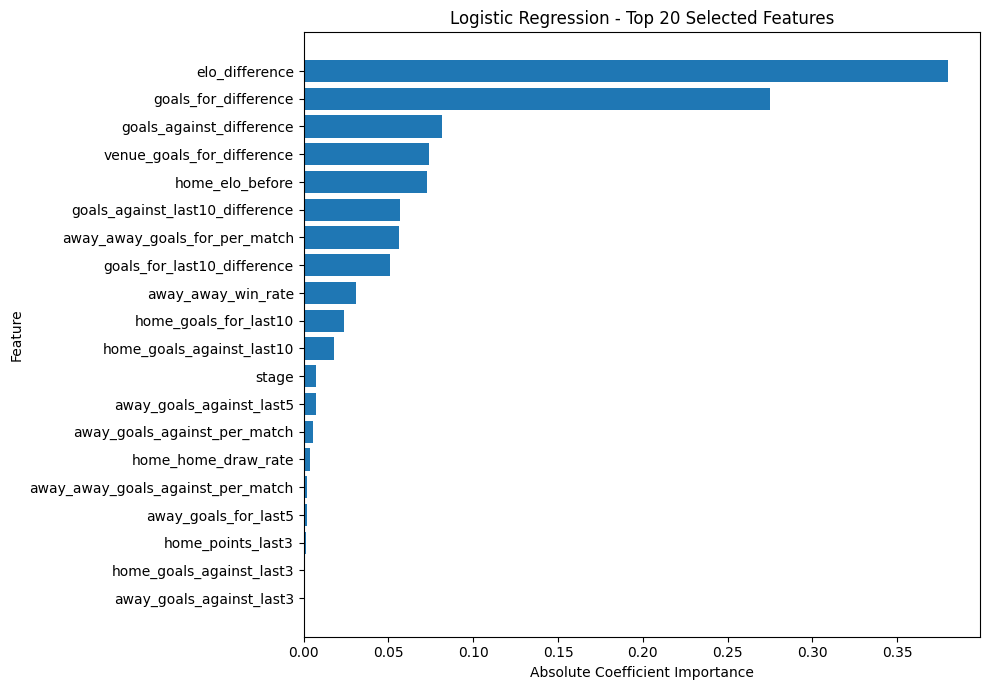

In [17]:
top_20_lr = (
    final_coefficient_importance
    .head(20)
    .sort_values(
        "Coefficient_Importance",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_20_lr["Feature"],
    top_20_lr["Coefficient_Importance"]
)

plt.xlabel("Absolute Coefficient Importance")

plt.ylabel("Feature")

plt.title("Logistic Regression - Top 20 Selected Features")

plt.tight_layout()
plt.show()

Summary & Test Confusion Matrix

Best hyperparameters: {'classifier__C': 0.01}
Best CV Macro F1     : 0.4412
Majority baseline accuracy: 0.4421


,Actual,Predicted
Away Win,30.40,26.35
Draw,25.40,35.68
Home Win,44.21,37.96


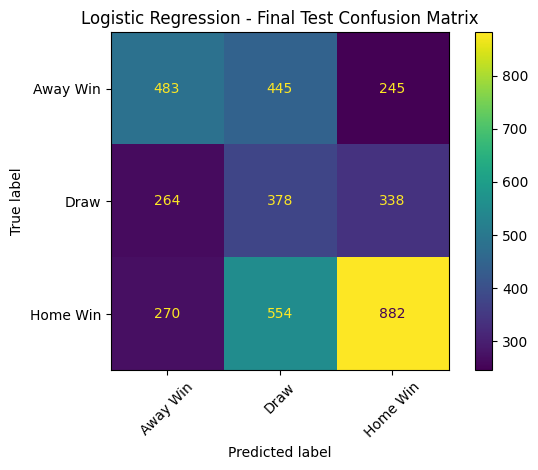

In [18]:
print("Best hyperparameters:", lr_grid_search.best_params_)
print("Best CV Macro F1     :", round(lr_grid_search.best_score_, 4))

# Majority baseline and predicted vs actual distribution (test)
maj = pd.Series(y_train_encoded).value_counts().idxmax()
print("Majority baseline accuracy:", round(accuracy_score(y_test_encoded, np.full(len(y_test_encoded), maj)), 4))

dist = pd.DataFrame({
    "Actual": pd.Series(y_test_encoded).value_counts(normalize=True).sort_index(),
    "Predicted": pd.Series(y_test_pred).value_counts(normalize=True).sort_index(),
})
dist.index = target_encoder.classes_
display((dist * 100).round(2))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded, y_test_pred,
    display_labels=target_encoder.classes_, xticks_rotation=45)
plt.title("Logistic Regression - Final Test Confusion Matrix")
plt.tight_layout()
plt.show()

Prepare final selected datasets

In [19]:
X_train_lr_final = (
    final_lr_selector.transform(
        X_train_corr
    )
)

X_val_lr_final = (
    final_lr_selector.transform(
        X_val_corr
    )
)

X_test_lr_final = (
    final_lr_selector.transform(
        X_test_corr
    )
)

X_train_lr_final = pd.DataFrame(
    X_train_lr_final,
    columns=final_lr_selected_features
)

X_val_lr_final = pd.DataFrame(
    X_val_lr_final,
    columns=final_lr_selected_features
)

X_test_lr_final = pd.DataFrame(
    X_test_lr_final,
    columns=final_lr_selected_features
)

print("Final selected training:", X_train_lr_final.shape)
print("Final selected validation:", X_val_lr_final.shape)
print("Final selected test:", X_test_lr_final.shape)

Final selected training: (17294, 27)
Final selected validation: (3818, 27)
Final selected test: (3859, 27)


Save model and feature-selection artifacts

In [20]:
# Save model-specific datasets (renamed so they don't clash with final_dataset)
X_train_lr_final.to_csv(
    os.path.join(LR_DIR, "X_train_lr_selected.csv"), index=False)

X_val_lr_final.to_csv(
    os.path.join(LR_DIR, "X_validation_lr_selected.csv"), index=False)

X_test_lr_final.to_csv(
    os.path.join(LR_DIR, "X_test_lr_selected.csv"), index=False)

# Save artifacts
joblib.dump(
    corr_drop_columns, os.path.join(LR_DIR, "correlation_drop_columns.joblib")
)

joblib.dump(
    lr_selector, os.path.join(LR_DIR, "l1_feature_selector_baseline.joblib")
)

joblib.dump(
    final_lr_selector, os.path.join(LR_DIR, "l1_feature_selector_final.joblib")
)

joblib.dump(
    best_lr_pipeline, os.path.join(LR_DIR, "logistic_regression_tuned_pipeline.joblib")
)

joblib.dump(
    best_threshold, os.path.join(LR_DIR, "calibrated_draw_threshold.joblib")
)

pd.DataFrame({"Feature": final_lr_selected_features}).to_csv(
    os.path.join(LR_DIR, "logistic_regression_selected_features.csv"), index=False)

# Save results
lr_selection_results.to_csv(os.path.join(LR_DIR, "l1_selection_C_results.csv"), index=False)

comparison_df.to_csv(os.path.join(LR_DIR, "logistic_regression_results.csv"))

final_coefficient_importance.to_csv(
    os.path.join(LR_DIR, "logistic_regression_coefficient_importance.csv"), index=False)

print("Logistic Regression outputs saved successfully to LR_DIR.")

Logistic Regression outputs saved successfully to LR_DIR.
